STAligner test


In [1]:
import easydict
from SANTO_utils import santo, simulate_stitching, evaluation
from SANTO_data import intersect
import numpy as np
from tqdm import tqdm
import scanpy as sc
import math
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/amanuky/miniforge3/envs/sant

In [2]:
sliceA = sc.read_h5ad("../../PASTE/DLFPC/data/151669_preprocessed.h5")
sliceB = sc.read_h5ad("../../PASTE/DLFPC/data/151670_preprocessed.h5")

/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


You choose align


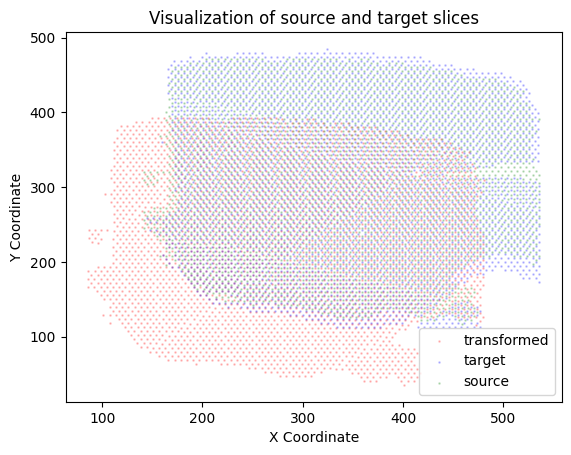

/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  0%|          | 0/20 [00:00<?, ?it/s]/Users/amanuky/miniforge3/envs/santo_env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:131: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
Epoch 19, Loss: 0.1594453603029251: 100%|██████████| 20/20 [04:27<00:00, 13.35s/it] 


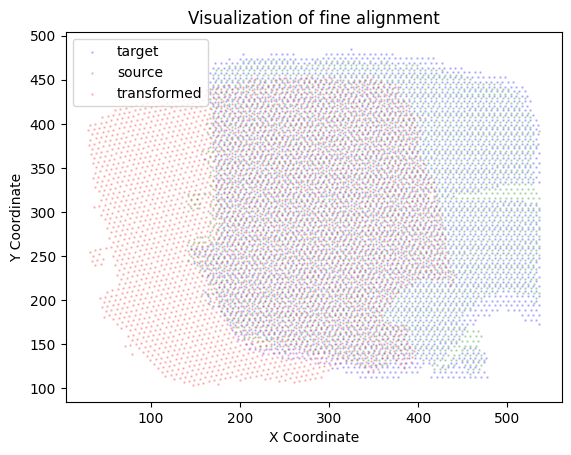

In [3]:
args = easydict.EasyDict({})
args.epochs = 20
args.lr = 0.001
args.k = 10
args.alpha = 0.1 # weight of transcriptional loss
args.diff_omics = False # whether to use different omics data
args.mode = 'align' # Choose the mode among 'align', 'stitch' and None
args.dimension = 2  # choose the dimension of coordinates (2 or 3)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

align_source_cor,trans_dict = santo(sliceB, sliceA, args)

In [4]:
new_slices = [sliceA, sliceB]
new_slices[1].obsm['spatial'] = align_source_cor

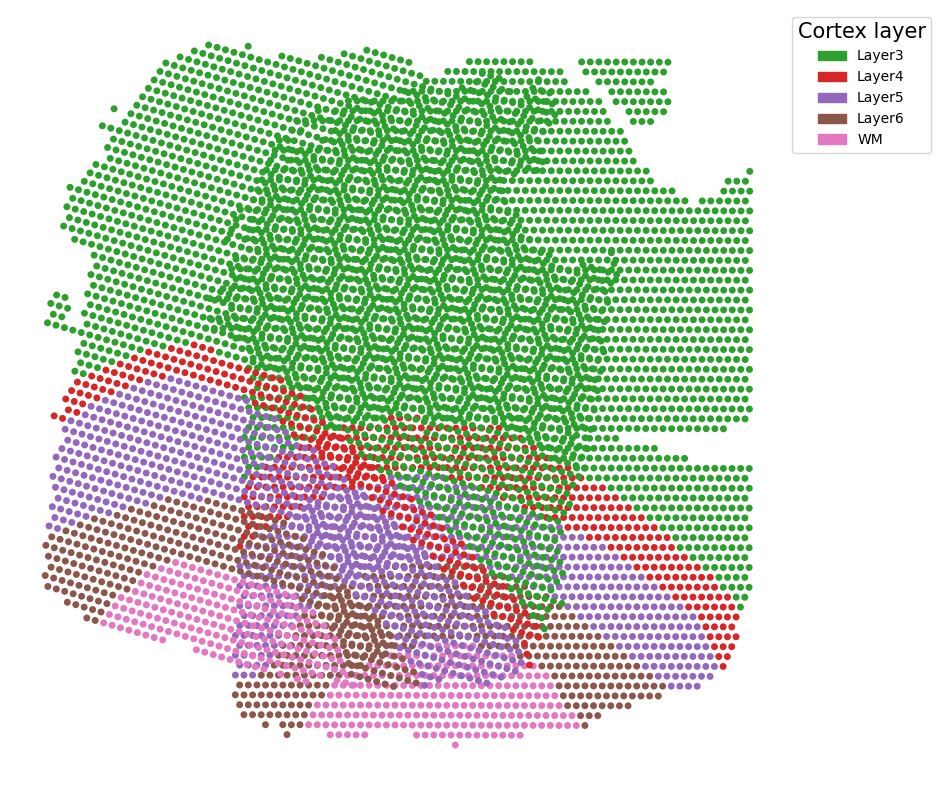

In [5]:
layer_to_color_map = {'Layer{0}'.format(i+1):sns.color_palette()[i] for i in range(6)}
layer_to_color_map['WM'] = sns.color_palette()[6]
def plot_slices_overlap(new_slices, layer_to_color_map=layer_to_color_map):
    plt.figure(figsize=(10,10))
    for i in range(len(new_slices)):
        adata = new_slices[i]
        colors = list(adata.obs['layer_guess_reordered'].astype('str').map(layer_to_color_map))
        plt.scatter(adata.obsm['spatial'][:,0],adata.obsm['spatial'][:,1],linewidth=0,s=100, marker=".",color=colors)
    plt.legend(handles=[mpatches.Patch(color=layer_to_color_map[adata.obs['layer_guess_reordered'].cat.categories[i]], label=adata.obs['layer_guess_reordered'].cat.categories[i]) for i in range(len(adata.obs['layer_guess_reordered'].cat.categories))],fontsize=10,title='Cortex layer',title_fontsize=15,bbox_to_anchor=(1, 1))
    plt.gca().invert_yaxis()
    plt.axis('off')
    plt.show()
    
plot_slices_overlap(new_slices)

In [6]:
new_slices[0].write_h5ad("results/151669adata_aligned.h5ad")
new_slices[1].write_h5ad("results/151670adata_aligned.h5ad")